# 5 Whys Agent — Graph Visualisation

Builds the LangGraph `StateGraph` in isolation (no LLMs, no DB) and renders it two ways:
1. **Mermaid diagram** — via `get_graph().draw_mermaid()` displayed inline with IPython
2. **PNG** — via `draw_mermaid_png()` for export

## Gemba result options

The `gemba_check` node accepts three operator inputs:

| Selection | Normalised to | Effect |
|-----------|--------------|--------|
| `OK` | `OK` | Branch closed — cause ruled out |
| `NOK` | `NOK` | LLM `root_cause_validator` decides whether to go deeper or to countermeasure |
| `ROOT_CAUSE` | `NOK` + `is_root_cause=True` injected into state | **Operator override** — bypasses `root_cause_validator` entirely; `_validate_router` sees `is_root_cause=True` and routes straight to `countermeasure_generator` |

> Note: because `ROOT_CAUSE` is normalised to `NOK` before reaching `_gemba_router`, the graph topology (edges) is unchanged — there is no new edge for `ROOT_CAUSE`. The shortcut is purely a state-level override.

In [7]:
from __future__ import annotations

from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display

# ── Minimal stub schemas (no pydantic / SQLite deps needed) ─────────────────
from typing import Annotated, Any, Optional
from langgraph.graph.message import add_messages
from langgraph.managed import RemainingSteps
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage


def _merge_why_nodes(existing: list, updates: list) -> list:
    by_path = {n['branch_path']: n for n in existing}
    for u in updates:
        by_path[u['branch_path']] = {**by_path.get(u['branch_path'], {}), **u}
    return list(by_path.values())


class OverallState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    phenomenon: str
    domain: str
    equipment_context: str
    domain_context: str
    max_depth: int
    investigation_id: str
    why_nodes: Annotated[list[dict], _merge_why_nodes]
    pending_hypotheses: list[dict]
    active_hypothesis: Optional[dict]
    current_depth: int
    current_branch_path: str
    remaining_steps: RemainingSteps
    report_path: str


class InputState(TypedDict):
    phenomenon: str
    domain: str
    equipment_context: str
    domain_context: str
    max_depth: int
    investigation_id: str

In [8]:
# ── Stub node functions (identity — graph topology only) ─────────────────────
def _noop(state): return {}

def _why_router(state) -> str:
    messages = state.get('messages', [])
    if messages and hasattr(messages[-1], 'tool_calls') and messages[-1].tool_calls:
        return 'tools'
    return 'dispatch'

def _gemba_router(state) -> str:
    """Routes on gemba_result ('OK' or 'NOK').

    'ROOT_CAUSE' is normalised to 'NOK' inside gemba_check() before this
    router runs, so only two edges exist in the graph.  The ROOT_CAUSE
    shortcut is handled via is_root_cause=True injected into active_hypothesis,
    which causes _validate_router to skip the LLM and go straight to
    countermeasure_generator.
    """
    active = state.get('active_hypothesis') or {}
    return 'OK' if active.get('gemba_result', 'NOK') == 'OK' else 'NOK'

def _validate_router(state) -> str:
    """Routes after root_cause_validator.

    Short-circuits to 'countermeasure' when:
      - is_root_cause=True  (operator selected ROOT_CAUSE, or LLM confirmed it)
      - depth > max_depth   (recursion limit reached)
      - remaining_steps <= 5 (LangGraph safety limit)
    Otherwise drills deeper via 'why_generator'.
    """
    active = state.get('active_hypothesis') or {}
    depth = active.get('depth', 1)
    max_depth = state.get('max_depth', 5)
    remaining = state.get('remaining_steps', 999)
    if active.get('is_root_cause', False) or depth > max_depth or remaining <= 5:
        return 'countermeasure'
    return 'deeper'

def _check_complete_router(state) -> str:
    return 'dispatch' if state.get('pending_hypotheses') else 'report'

In [9]:
# ── Build graph (mirrors _build_graph() in agent.py exactly) ─────────────────
builder = StateGraph(OverallState, input_schema=InputState)

for node_name in [
    'intake', 'why_generator', 'why_tools', 'gemba_dispatcher',
    'gemba_check', 'branch_closer', 'root_cause_validator',
    'countermeasure_generator', 'check_complete', 'report_generator',
]:
    builder.add_node(node_name, _noop)

builder.add_edge(START, 'intake')
builder.add_edge('intake', 'why_generator')
builder.add_conditional_edges(
    'why_generator', _why_router,
    {'tools': 'why_tools', 'dispatch': 'gemba_dispatcher'},
)
builder.add_edge('why_tools', 'why_generator')
builder.add_edge('gemba_dispatcher', 'gemba_check')
builder.add_conditional_edges(
    'gemba_check', _gemba_router,
    {'OK': 'branch_closer', 'NOK': 'root_cause_validator'},
)
builder.add_edge('branch_closer', 'check_complete')
builder.add_conditional_edges(
    'root_cause_validator', _validate_router,
    {'countermeasure': 'countermeasure_generator', 'deeper': 'why_generator'},
)
builder.add_edge('countermeasure_generator', 'check_complete')
builder.add_conditional_edges(
    'check_complete', _check_complete_router,
    {'dispatch': 'gemba_dispatcher', 'report': 'report_generator'},
)
builder.add_edge('report_generator', END)

# Compile without checkpointer — topology only
graph = builder.compile(interrupt_before=['gemba_check'])
print('Graph compiled successfully.')

Graph compiled successfully.


## Mermaid source

The raw Mermaid markup — copy this into any Mermaid renderer.

In [10]:
mermaid_src = graph.get_graph().draw_mermaid()
print(mermaid_src)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	intake(intake)
	why_generator(why_generator)
	why_tools(why_tools)
	gemba_dispatcher(gemba_dispatcher)
	gemba_check(gemba_check<hr/><small><em>__interrupt = before</em></small>)
	branch_closer(branch_closer)
	root_cause_validator(root_cause_validator)
	countermeasure_generator(countermeasure_generator)
	check_complete(check_complete)
	report_generator(report_generator)
	__end__([<p>__end__</p>]):::last
	__start__ --> intake;
	branch_closer --> check_complete;
	check_complete -. &nbsp;dispatch&nbsp; .-> gemba_dispatcher;
	check_complete -. &nbsp;report&nbsp; .-> report_generator;
	countermeasure_generator --> check_complete;
	gemba_check -. &nbsp;OK&nbsp; .-> branch_closer;
	gemba_check -. &nbsp;NOK&nbsp; .-> root_cause_validator;
	gemba_dispatcher --> gemba_check;
	intake --> why_generator;
	root_cause_validator -. &nbsp;countermeasure&nbsp; .-> countermeasure_generator;
	root_cause_validat

## Inline PNG render

Requires `pygraphviz` **or** network access to the Mermaid.ink renderer.
Falls back gracefully if neither is available.

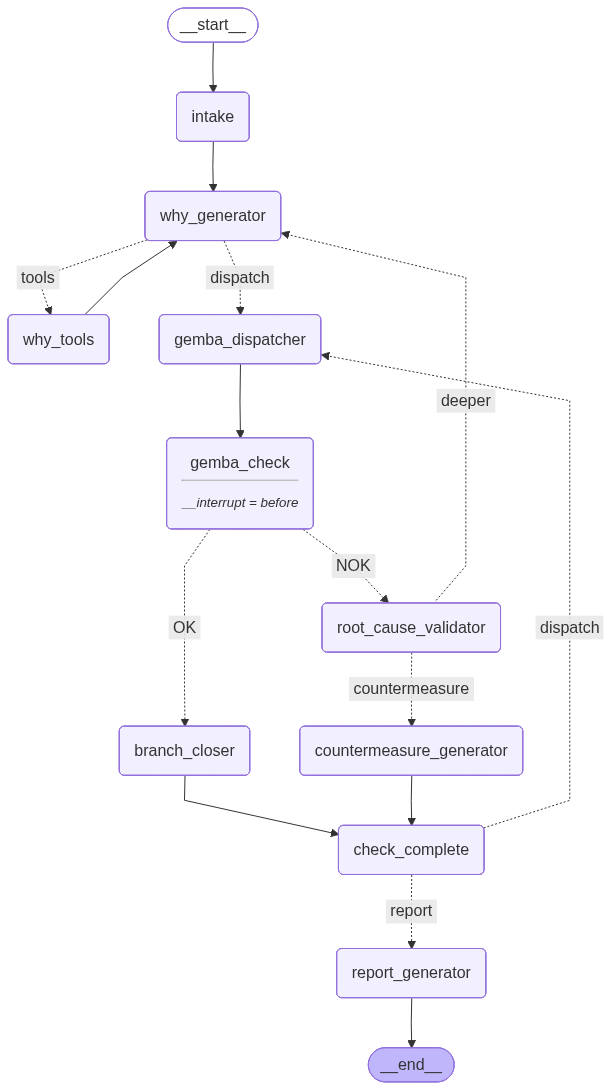

In [11]:
try:
    png_bytes = graph.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
except Exception as e:
    print(f'PNG render unavailable ({e}).\nUse the Mermaid source above instead.')

## Node & edge summary

In [12]:
g = graph.get_graph()

print('Nodes')
print('-----')
for node in g.nodes:
    print(f'  {node}')

print()
print('Edges')
print('-----')
for edge in g.edges:
    label = f'  [{edge.conditional}]' if edge.conditional else ''
    print(f'  {edge.source} -> {edge.target}{label}')

Nodes
-----
  __start__
  intake
  why_generator
  why_tools
  gemba_dispatcher
  gemba_check
  branch_closer
  root_cause_validator
  countermeasure_generator
  check_complete
  report_generator
  __end__

Edges
-----
  __start__ -> intake
  branch_closer -> check_complete
  check_complete -> gemba_dispatcher  [True]
  check_complete -> report_generator  [True]
  countermeasure_generator -> check_complete
  gemba_check -> branch_closer  [True]
  gemba_check -> root_cause_validator  [True]
  gemba_dispatcher -> gemba_check
  intake -> why_generator
  root_cause_validator -> countermeasure_generator  [True]
  root_cause_validator -> why_generator  [True]
  why_generator -> gemba_dispatcher  [True]
  why_generator -> why_tools  [True]
  why_tools -> why_generator
  report_generator -> __end__
